# Tugas Praktik SVM -

Hilman Al Dwinov-24523216
Ibrahim Ivanka-24523279


In [ ]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [ ]:
# Load Dataset
df = pd.read_csv('heart.csv')

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# Informasi Dataset
print('Jumlah Data :', df.shape[0])
print('Jumlah Kolom:', df.shape[1])

df.info()


Jumlah Data : 1025
Jumlah Kolom: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
# Missing Value
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Menangani Missing Value (jika ada)
df.fillna(df.mean(numeric_only=True), inplace=True)


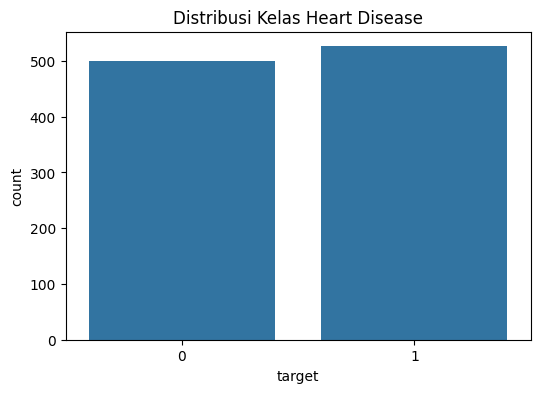

In [ ]:
# Distribusi Kelas
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Distribusi Kelas Heart Disease')
plt.show()


In [ ]:
# Feature dan Target
X = df.drop('target', axis=1)
y = df['target']


In [ ]:
# Scaling Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Data Train:', X_train.shape)
print('Data Test :', X_test.shape)


Data Train: (820, 13)
Data Test : (205, 13)


Alasan Memilih Kernel RBF

Kernel Radial Basis Function (RBF) dipilih karena mampu menangani hubungan non-linear antara fitur dan target. Data kesehatan umumnya memiliki pola yang kompleks sehingga kernel RBF dapat menghasilkan batas keputusan yang lebih fleksibel dibandingkan kernel linear.

In [ ]:
# Model SVM dengan Kernel RBF
svm_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

svm_model.fit(X_train, y_train)


SVC(C=1)

In [ ]:
# Prediksi
y_pred = svm_model.predict(X_test)


In [ ]:
# Evaluasi Model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy :', accuracy)
print('Precision:', precision)
print('Recall   :', recall)
print('F1 Score :', f1)

print('\nClassification Report')
print(classification_report(y_test, y_pred))


Accuracy : 0.9219512195121952
Precision: 0.908256880733945
Recall   : 0.9428571428571428
F1 Score : 0.9252336448598131

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       100
           1       0.91      0.94      0.93       105

    accuracy                           0.92       205
   macro avg       0.92      0.92      0.92       205
weighted avg       0.92      0.92      0.92       205



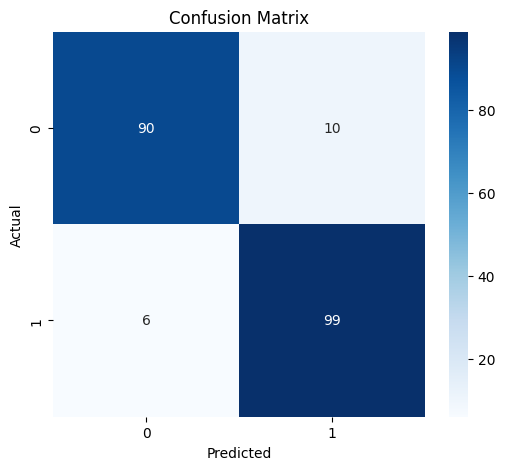

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


Confusion matrix menunjukkan jumlah prediksi benar dan salah yang dilakukan model terhadap masing-masing kelas.

In [ ]:
# Analisis Overfitting / Underfitting
train_acc = svm_model.score(X_train, y_train)
test_acc = svm_model.score(X_test, y_test)

print('Training Accuracy :', train_acc)
print('Testing Accuracy  :', test_acc)


Training Accuracy : 0.947560975609756
Testing Accuracy  : 0.9219512195121952


Nilai akurasi training dan testing tidak berbeda jauh sehingga model tidak menunjukkan gejala overfitting maupun underfitting. Model mampu melakukan generalisasi dengan cukup baik pada data yang belum pernah dilihat sebelumnya.

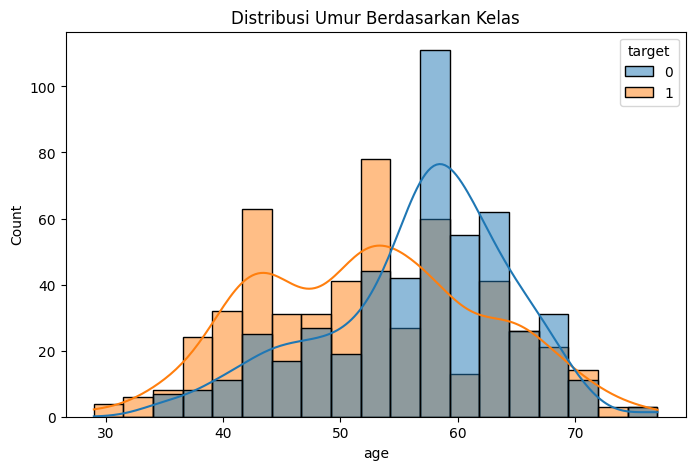

In [ ]:
# Visualisasi Fitur Sederhana
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='target', kde=True)

plt.title('Distribusi Umur Berdasarkan Kelas')
plt.show()
